# Vote Splitting and the Spoiler Effect

This notebook studies a classic question in electoral politics: when does a similar candidate change the winner, and which electoral systems are most vulnerable to that kind of vote splitting?

Everything here is defined inline in the notebook. We use a stylized center-left majority electorate, compare races with and without a nearby spoiler candidate, and then sweep over coalition size and candidate proximity.

---
## 0. Imports and configuration

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

cwd = Path.cwd().resolve()
if (cwd / "configs").exists() and (cwd / "electoral_sim").exists():
    REPO_ROOT = cwd
else:
    REPO_ROOT = cwd.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from electoral_sim.ballots import BallotProfile
from electoral_sim.candidates import fixed_candidates
from electoral_sim.electorate import gaussian_mixture_electorate
from electoral_sim.metrics import compute_metrics
from electoral_sim.systems import (
    ApprovalVoting,
    BordaCount,
    CondorcetSchulze,
    InstantRunoff,
    Plurality,
    ScoreVoting,
    TwoRoundRunoff,
)

sns.set_theme(style="whitegrid")

SYSTEMS = [
    Plurality(),
    TwoRoundRunoff(),
    InstantRunoff(),
    ApprovalVoting(),
    ScoreVoting(),
    CondorcetSchulze(),
    BordaCount(),
]

LEFT_MEAN = [0.36, 0.48]
RIGHT_MEAN = [0.72, 0.56]
LEFT_COV = [[0.018, 0.004], [0.004, 0.018]]
RIGHT_COV = [[0.018, -0.004], [-0.004, 0.018]]
LEFT_MAIN = [0.34, 0.48]
RIGHT = [0.74, 0.56]
CANONICAL_LEFT_WEIGHT = 0.59
CANONICAL_OFFSET = 0.06

---
## 1. Inline scenario family

We define one family of spoiler scenarios directly in the notebook.

- The electorate has a **center-left bloc** and a **right bloc**.
- The baseline race has two candidates: `L-Main` and `R-Unity`.
- The spoiler race adds a nearby `L-Spoiler` candidate.

The two key knobs are:

- `left_weight`: how large the left coalition is.
- `offset`: how far the spoiler sits from the main left candidate.

In [2]:
def make_electorate(left_weight, seed):
    return gaussian_mixture_electorate(
        5000,
        [
            {"weight": left_weight, "mean": LEFT_MEAN, "cov": LEFT_COV},
            {"weight": 1 - left_weight, "mean": RIGHT_MEAN, "cov": RIGHT_COV},
        ],
        rng=np.random.default_rng(seed),
        dim_names=["economic", "social"],
    )


def make_candidates(offset):
    spoiler = [LEFT_MAIN[0] + offset, LEFT_MAIN[1] + 0.30 * offset]
    with_spoiler = fixed_candidates(
        [LEFT_MAIN, spoiler, RIGHT],
        ["L-Main", "L-Spoiler", "R-Unity"],
    )
    without_spoiler = fixed_candidates(
        [LEFT_MAIN, RIGHT],
        ["L-Main", "R-Unity"],
    )
    return with_spoiler, without_spoiler


def winner_side(label):
    return "L" if label.startswith("L") else "R"

---
## 2. A canonical spoiler example

We start with a left coalition that is large enough to win if it coordinates on one candidate, but vulnerable if that coalition splits.

In [3]:
electorate = make_electorate(CANONICAL_LEFT_WEIGHT, 111)
with_spoiler, without_spoiler = make_candidates(CANONICAL_OFFSET)

canonical_records = []
for system in SYSTEMS:
    ballots_without = BallotProfile.from_preferences(electorate, without_spoiler)
    result_without = system.run(ballots_without, without_spoiler)
    metrics_without = compute_metrics(result_without, electorate, without_spoiler)

    ballots_with = BallotProfile.from_preferences(electorate, with_spoiler)
    result_with = system.run(ballots_with, with_spoiler)
    metrics_with = compute_metrics(result_with, electorate, with_spoiler)

    winner_without = without_spoiler.labels[result_without.winner_indices[0]]
    winner_with = with_spoiler.labels[result_with.winner_indices[0]]
    canonical_records.append(
        {
            "system": system.name,
            "winner_without_spoiler": winner_without,
            "winner_with_spoiler": winner_with,
            "spoiler_flip": winner_side(winner_without) != winner_side(winner_with),
            "d_median_without": metrics_without.distance_to_median,
            "d_median_with": metrics_with.distance_to_median,
        }
    )

canonical_df = pd.DataFrame(canonical_records)
canonical_df.round(4)

,system,winner_without_spoiler,winner_with_spoiler,spoiler_flip,d_median_without,d_median_with
0,Plurality (FPTP),L-Main,R-Unity,True,0.1565,0.2515
1,Two-Round Runoff,L-Main,L-Main,False,0.1565,0.1565
2,Instant Runoff (IRV),L-Main,L-Main,False,0.1565,0.1565
3,Approval Voting,L-Main,L-Main,False,0.1565,0.1565
4,Score Voting,L-Main,L-Spoiler,False,0.1565,0.0941
5,Condorcet (Schulze),L-Main,L-Spoiler,False,0.1565,0.0941
6,Borda Count,L-Main,L-Spoiler,False,0.1565,0.0941


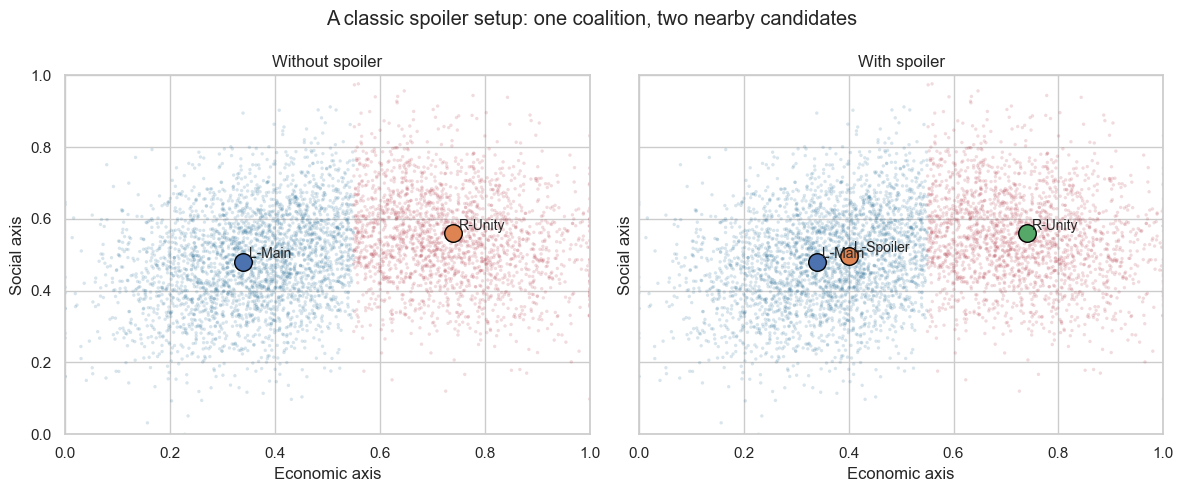

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

colors = np.where(electorate.preferences[:, 0] < 0.55, "#2a6f97", "#b23a48")

for ax, candidates, title in [
    (axes[0], without_spoiler, "Without spoiler"),
    (axes[1], with_spoiler, "With spoiler"),
]:
    ax.scatter(
        electorate.preferences[:, 0],
        electorate.preferences[:, 1],
        s=6,
        alpha=0.18,
        c=colors,
        linewidths=0,
    )
    for label, pos in zip(candidates.labels, candidates.positions):
        ax.scatter(pos[0], pos[1], s=160, edgecolor="black", linewidth=1.0)
        ax.text(pos[0] + 0.01, pos[1] + 0.01, label, fontsize=10)
    ax.set_title(title)
    ax.set_xlabel("Economic axis")
    ax.set_ylabel("Social axis")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)

plt.suptitle("A classic spoiler setup: one coalition, two nearby candidates")
plt.tight_layout()
plt.show()

---
## 3. Sweep over coalition size and spoiler proximity

The canonical case is useful, but the spoiler effect is really a *region* of parameter space.

So we vary:

- `left_weight` from `0.51` to `0.67`
- `offset` from `0.02` to `0.18`

For each cell we compare the winner **with** and **without** the extra left candidate.

In [5]:
records = []
left_weights = np.linspace(0.51, 0.67, 5)
offsets = np.linspace(0.02, 0.18, 5)

for i, left_weight in enumerate(left_weights):
    for j, offset in enumerate(offsets):
        electorate = make_electorate(float(left_weight), 1000 + 17 * i + j)
        with_spoiler, without_spoiler = make_candidates(float(offset))
        ballots_with = BallotProfile.from_preferences(electorate, with_spoiler)
        ballots_without = BallotProfile.from_preferences(electorate, without_spoiler)

        for system in SYSTEMS:
            result_with = system.run(ballots_with, with_spoiler)
            result_without = system.run(ballots_without, without_spoiler)
            metrics_with = compute_metrics(result_with, electorate, with_spoiler)
            metrics_without = compute_metrics(result_without, electorate, without_spoiler)

            winner_with = with_spoiler.labels[result_with.winner_indices[0]]
            winner_without = without_spoiler.labels[result_without.winner_indices[0]]

            records.append(
                {
                    "system": system.name,
                    "left_weight": round(float(left_weight), 2),
                    "offset": round(float(offset), 2),
                    "winner_without": winner_without,
                    "winner_with": winner_with,
                    "spoiler": int(winner_side(winner_without) != winner_side(winner_with)),
                    "delta_d_median": (
                        metrics_with.distance_to_median - metrics_without.distance_to_median
                    ),
                }
            )

sweep_df = pd.DataFrame(records)
sweep_df.head()

,system,left_weight,offset,winner_without,winner_with,spoiler,delta_d_median
0,Plurality (FPTP),0.51,0.02,R-Unity,R-Unity,0,0.000000
1,Two-Round Runoff,0.51,0.02,R-Unity,L-Spoiler,1,-0.024978
2,Instant Runoff (IRV),0.51,0.02,R-Unity,L-Spoiler,1,-0.024978
3,Approval Voting,0.51,0.02,R-Unity,R-Unity,0,0.000000
4,Score Voting,0.51,0.02,L-Main,L-Spoiler,0,-0.020820


---
## 4. System-level spoiler rates

In [6]:
summary = (
    sweep_df.groupby("system")
    .agg(
        spoiler_rate=("spoiler", "mean"),
        spoiler_cases=("spoiler", "sum"),
        avg_delta_d_median=("delta_d_median", "mean"),
    )
    .reset_index()
    .sort_values(["spoiler_rate", "avg_delta_d_median"], ascending=[False, False])
)

summary["spoiler_rate"] = summary["spoiler_rate"].round(3)
summary["avg_delta_d_median"] = summary["avg_delta_d_median"].round(4)
summary

,system,spoiler_rate,spoiler_cases,avg_delta_d_median
4,Plurality (FPTP),0.44,11,0.0378
1,Borda Count,0.16,4,-0.0861
2,Condorcet (Schulze),0.16,4,-0.0861
5,Score Voting,0.12,3,-0.0859
3,Instant Runoff (IRV),0.04,1,-0.0099
6,Two-Round Runoff,0.04,1,-0.0099
0,Approval Voting,0.00,0,0.0000


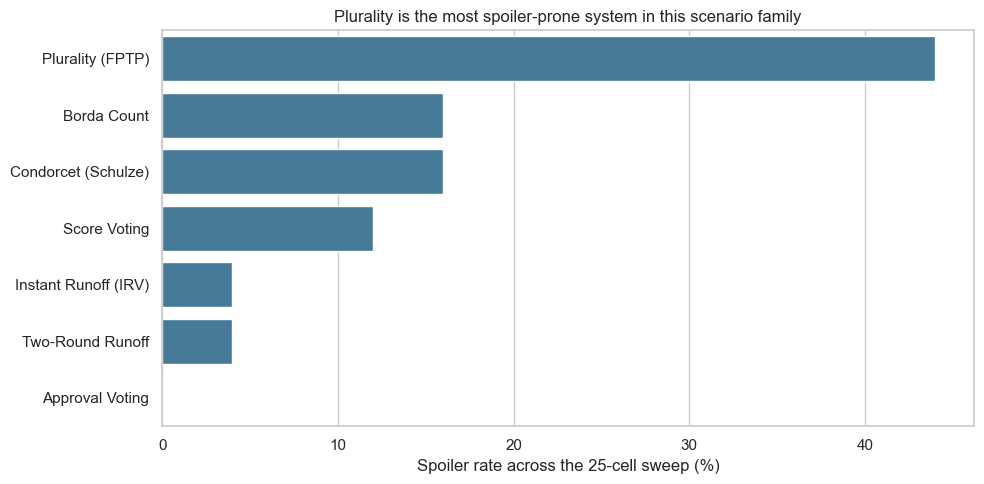

In [7]:
plot_df = summary.copy()
plot_df["spoiler_rate_pct"] = 100 * plot_df["spoiler_rate"]

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="spoiler_rate_pct", y="system", color="#3a7ca5")
plt.xlabel("Spoiler rate across the 25-cell sweep (%)")
plt.ylabel("")
plt.title("Plurality is the most spoiler-prone system in this scenario family")
plt.tight_layout()
plt.show()

---
## 5. Where do spoiler flips happen?

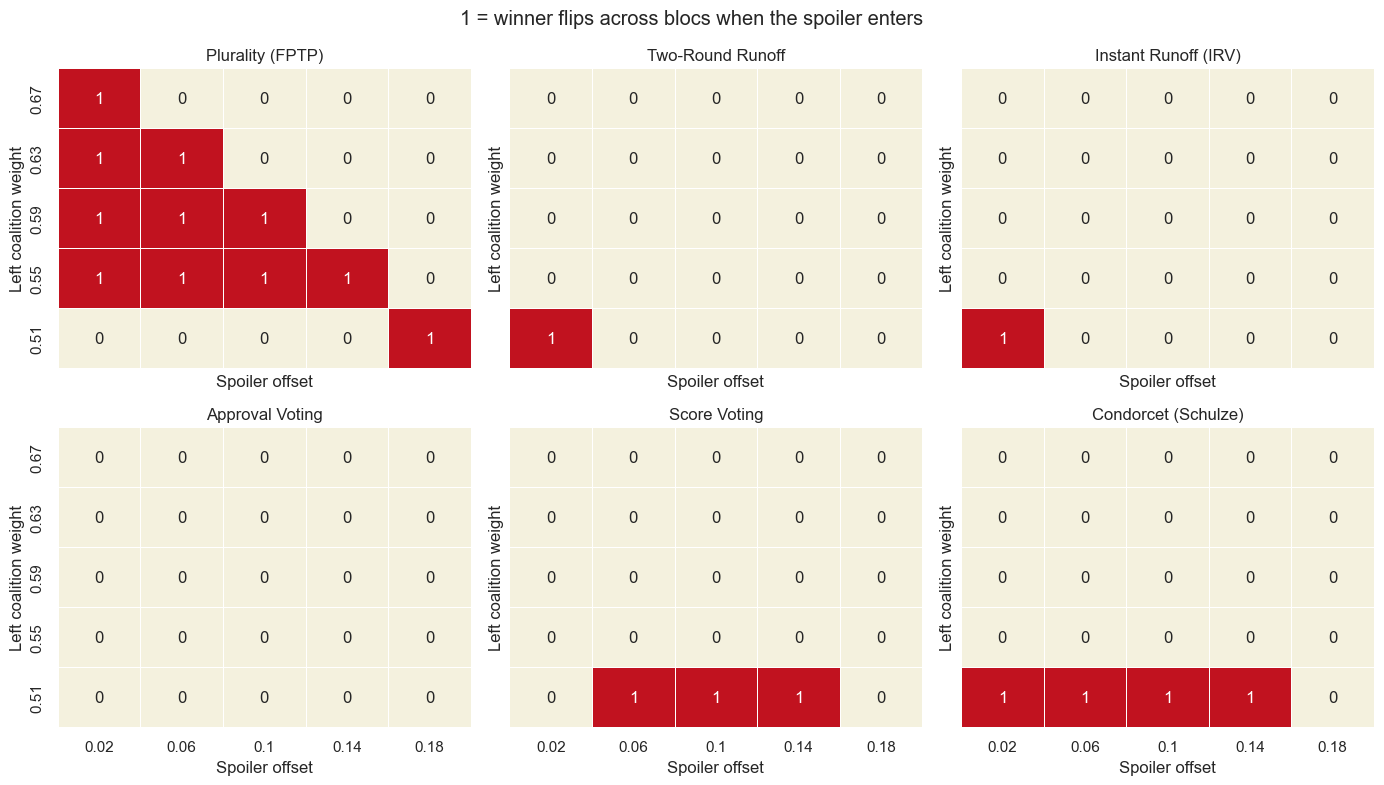

In [8]:
systems_to_plot = [
    "Plurality (FPTP)",
    "Two-Round Runoff",
    "Instant Runoff (IRV)",
    "Approval Voting",
    "Score Voting",
    "Condorcet (Schulze)",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)

for ax, system_name in zip(axes.flat, systems_to_plot):
    sub = sweep_df[sweep_df["system"] == system_name]
    pivot = sub.pivot(index="left_weight", columns="offset", values="spoiler")
    sns.heatmap(
        pivot.sort_index(ascending=False),
        ax=ax,
        cmap=sns.color_palette(["#f4f1de", "#c1121f"], as_cmap=True),
        vmin=0,
        vmax=1,
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        annot=True,
        fmt=".0f",
    )
    ax.set_title(system_name)
    ax.set_xlabel("Spoiler offset")
    ax.set_ylabel("Left coalition weight")

plt.suptitle("1 = winner flips across blocs when the spoiler enters")
plt.tight_layout()
plt.show()

---
## 6. Does the spoiler make the outcome worse?

A winner change is not the whole story. We also compare how much the extra candidate moves each system's winner toward or away from the electorate's geometric median.

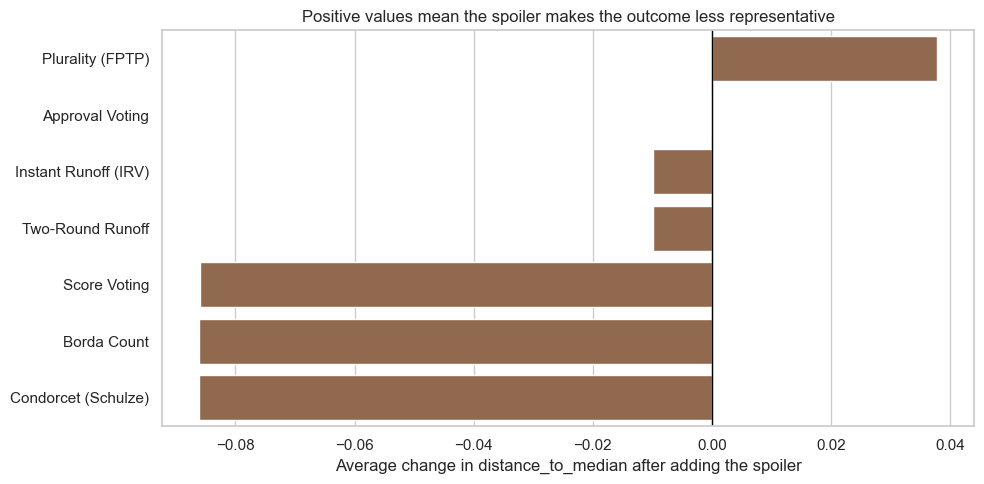

In [9]:
delta_plot = summary.sort_values("avg_delta_d_median", ascending=False).copy()

plt.figure(figsize=(10, 5))
sns.barplot(data=delta_plot, x="avg_delta_d_median", y="system", color="#9c6644")
plt.axvline(0.0, color="black", linewidth=1.0)
plt.xlabel("Average change in distance_to_median after adding the spoiler")
plt.ylabel("")
plt.title("Positive values mean the spoiler makes the outcome less representative")
plt.tight_layout()
plt.show()

In [10]:
plurality_cases = sweep_df[sweep_df["system"] == "Plurality (FPTP)"][
    ["left_weight", "offset", "winner_without", "winner_with", "spoiler", "delta_d_median"]
]
plurality_cases

,left_weight,offset,winner_without,winner_with,spoiler,delta_d_median
0,0.51,0.02,R-Unity,R-Unity,0,0.000000
7,0.51,0.06,R-Unity,R-Unity,0,0.000000
14,0.51,0.10,R-Unity,R-Unity,0,0.000000
21,0.51,0.14,R-Unity,R-Unity,0,0.000000
28,0.51,0.18,L-Main,R-Unity,1,0.008002
35,0.55,0.02,L-Main,R-Unity,1,0.055500
42,0.55,0.06,L-Main,R-Unity,1,0.047144
49,0.55,0.10,L-Main,R-Unity,1,0.057156
56,0.55,0.14,L-Main,R-Unity,1,0.043171
63,0.55,0.18,L-Main,L-Main,0,0.000000


---
## 8. Conclusion

In this notebook's canonical center-left split example, **Plurality** is the clearest spoiler victim: the left coalition wins when it fields one candidate, but loses to `R-Unity` once a nearby `L-Spoiler` enters. By contrast, **IRV**, **Two-Round Runoff**, and **Approval Voting** keep the winner on the left, while **Score**, **Condorcet**, and **Borda** go one step further and often upgrade from `L-Main` to the more compromise-friendly `L-Spoiler`.

Across the full 5 x 5 sweep of coalition size and spoiler proximity, the systems separate sharply. **Plurality shows a spoiler flip in 44% of cases**, compared with **4% for IRV**, **4% for Two-Round Runoff**, and **0% for Approval Voting**. **Score Voting**, **Condorcet**, and **Borda** still register some winner changes when the extra candidate enters, but those changes are usually *within* the left coalition rather than across blocs.

The metric pattern lines up with the winner pattern. On average, adding the spoiler candidate makes Plurality outcomes **farther** from the electorate's geometric median, while systems like Score, Condorcet, and Borda move the outcome **closer** to the center on average. In this sweep, Score's average change in `distance_to_median` is -0.0859, which means the extra similar candidate typically helps it identify a better compromise rather than simply splitting a coalition.